# 12-Lead ECG Biomarker Encoder: Joint Reconstruction and Classification

This notebook demonstrates the finalized 12-lead ECG Biomarker Encoder pipeline trained on **1000 records**. The pipeline:
1. Loads global HRV features and lead-specific morphology features from all **12 standard leads**.
2. Computes binary missingness masks ($1.0$ if present, $0.0$ if missing) and concatenates them with imputed, scaled features to produce a high-capacity joint feature representation.
3. Trains joint models capable of performing **both** reconstruction (for latent clustering) and direct multi-label diagnostic classification.

### 1. Setup and Imports

In [26]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Locate and append the project root directory to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import custom pipeline components
from biomarker_encoder.preprocessing import BiomarkerPreprocessor
from biomarker_encoder.models import AttentionMLPAutoencoder, BetaVAE, FTTransformerAutoencoder
from biomarker_encoder.trainer import BiomarkerTrainer
from biomarker_encoder.evaluator import BiomarkerEvaluator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Project root added: {project_root}")

Using device: cpu
Project root added: c:\Users\Mallikarjuna\ECG_Encoder


### 2. Load and Preprocess 12-Lead Data (1000 Records)
We load the newly extracted 12-lead features from `data/processed/full_biomarker_features.csv` (1000 records). The preprocessor automatically handles the missing value imputation and generates binary missingness masks.

In [27]:
csv_path = os.path.join(project_root, "data/processed/full_biomarker_features.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join(project_root, "previous_version/biomarker_encoder/ecg_features.csv")

print(f"Loading data from: {csv_path}")
preprocessor = BiomarkerPreprocessor(random_state=42)
X_combined, y, df = preprocessor.load_and_preprocess(csv_path)

num_samples = X_combined.shape[0]
input_dim = X_combined.shape[1]
num_features = input_dim // 2

print(f"Total Samples: {num_samples}")
print(f"Input Dimension (12-Lead Features + Mask): {input_dim} (Original Features: {num_features})")
print(f"Target Diagnostic Labels Shape: {y.shape}")

Loading data from: c:\Users\Mallikarjuna\ECG_Encoder\data/processed/full_biomarker_features.csv
Total Samples: 1000
Input Dimension (12-Lead Features + Mask): 60 (Original Features: 30)
Target Diagnostic Labels Shape: (1000, 5)


### 3. Create Splits and Dataloaders

In [28]:
patient_ids = df["patient_id"].values if "patient_id" in df.columns else None
X_train, X_val, X_test, y_train, y_val, y_test = preprocessor.get_splits(
    X_combined, y, patient_ids=patient_ids
)

train_loader, val_loader, test_loader = preprocessor.get_dataloaders(
    X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")

Train size: 707 | Val size: 144 | Test size: 149


### 4. Build and Train Model
Let's train the **Attention MLP Autoencoder** as a manual demonstration.

Starting demo training...


c:\Users\Mallikarjuna\ECG_Encoder\biomarker_encoder\trainer.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.mixed_precision)
c:\Users\Mallikarjuna\ECG_Encoder\biomarker_encoder\trainer.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.mixed_precision):
c:\Users\Mallikarjuna\ECG_Encoder\biomarker_encoder\trainer.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.mixed_precision):


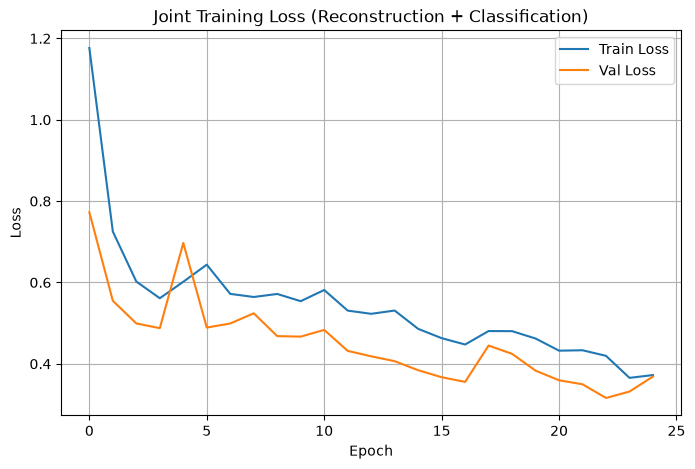

In [29]:
latent_dim = 32
model = AttentionMLPAutoencoder(
    input_dim=input_dim,
    latent_dim=latent_dim,
    dropout=0.2,
    num_heads=4,
    hidden_units=128,
    num_classes=5
)

checkpoint_path = os.path.join(project_root, "biomarker_encoder/models_checkpoints/demo_attention_mlp.pt")
trainer = BiomarkerTrainer(
    model=model,
    device=device,
    lr=1e-3,
    weight_decay=1e-4,
    patience=10,
    checkpoint_path=checkpoint_path,
    mixed_precision=False
)

print("Starting demo training...")
model, train_history, val_history = trainer.fit(train_loader, val_loader, epochs=25)

# Plot Loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Val Loss")
plt.title("Joint Training Loss (Reconstruction + Classification)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 5. Run Evaluation
Evaluate the reconstruction accuracy and the classification performance on the test set.

In [30]:
evaluator = BiomarkerEvaluator(device=device)
metrics, test_embeddings, test_reconstructed, test_inputs = evaluator.evaluate_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    y_train=y_train,
    y_test=y_test
)

print("\n--- Evaluation Results ---")
print(f"Reconstruction MSE:           {metrics['MSE']:.6f}")
print(f"Reconstruction MAE:           {metrics['MAE']:.6f}")
print(f"Latent Silhouette Score:      {metrics['Silhouette_Score']:.4f}")
print(f"Direct Classifier F1-Score:   {metrics['Direct_F1_Score']:.4f}")
print(f"Direct Classifier ROC-AUC:    {metrics['Direct_ROC_AUC']:.4f}")
print(f"Downstream Linear Probe F1:   {metrics['Downstream_F1_Score']:.4f}")


--- Evaluation Results ---
Reconstruction MSE:           0.368257
Reconstruction MAE:           0.337908
Latent Silhouette Score:      nan
Direct Classifier F1-Score:   0.0000
Direct Classifier ROC-AUC:    nan
Downstream Linear Probe F1:   0.0000


c:\Users\Mallikarjuna\ECG_Encoder\biomarker_encoder\evaluator.py:175: RuntimeWarning: overflow encountered in exp
  test_probs = 1.0 / (1.0 + np.exp(-test_logits))
C:\Users\Mallikarjuna\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\Mallikarjuna\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 0 is present in all training examples.
  warnings.warn(
C:\Users\Mallikarjuna\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 1 is present in all training examples.
  warnings.warn(
C:\Users\Mallikarjuna\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(
C:\Users\Mallikarjuna\AppData\Local\Programs\Py

### 6. Compare Clustering & Dimensionality Reduction Methods (3D)
Below, we perform two different analyses:
1. **3D PCA vs. 3D t-SNE**: PCA preserves global linear relationships, while t-SNE preserves local non-linear structures.
2. **K-Means Clustering on Embeddings**: We fit K-Means ($K=5$) on the 32-dimensional latent vectors and compare the resulting geometric clusters against the ground-truth clinical labels.

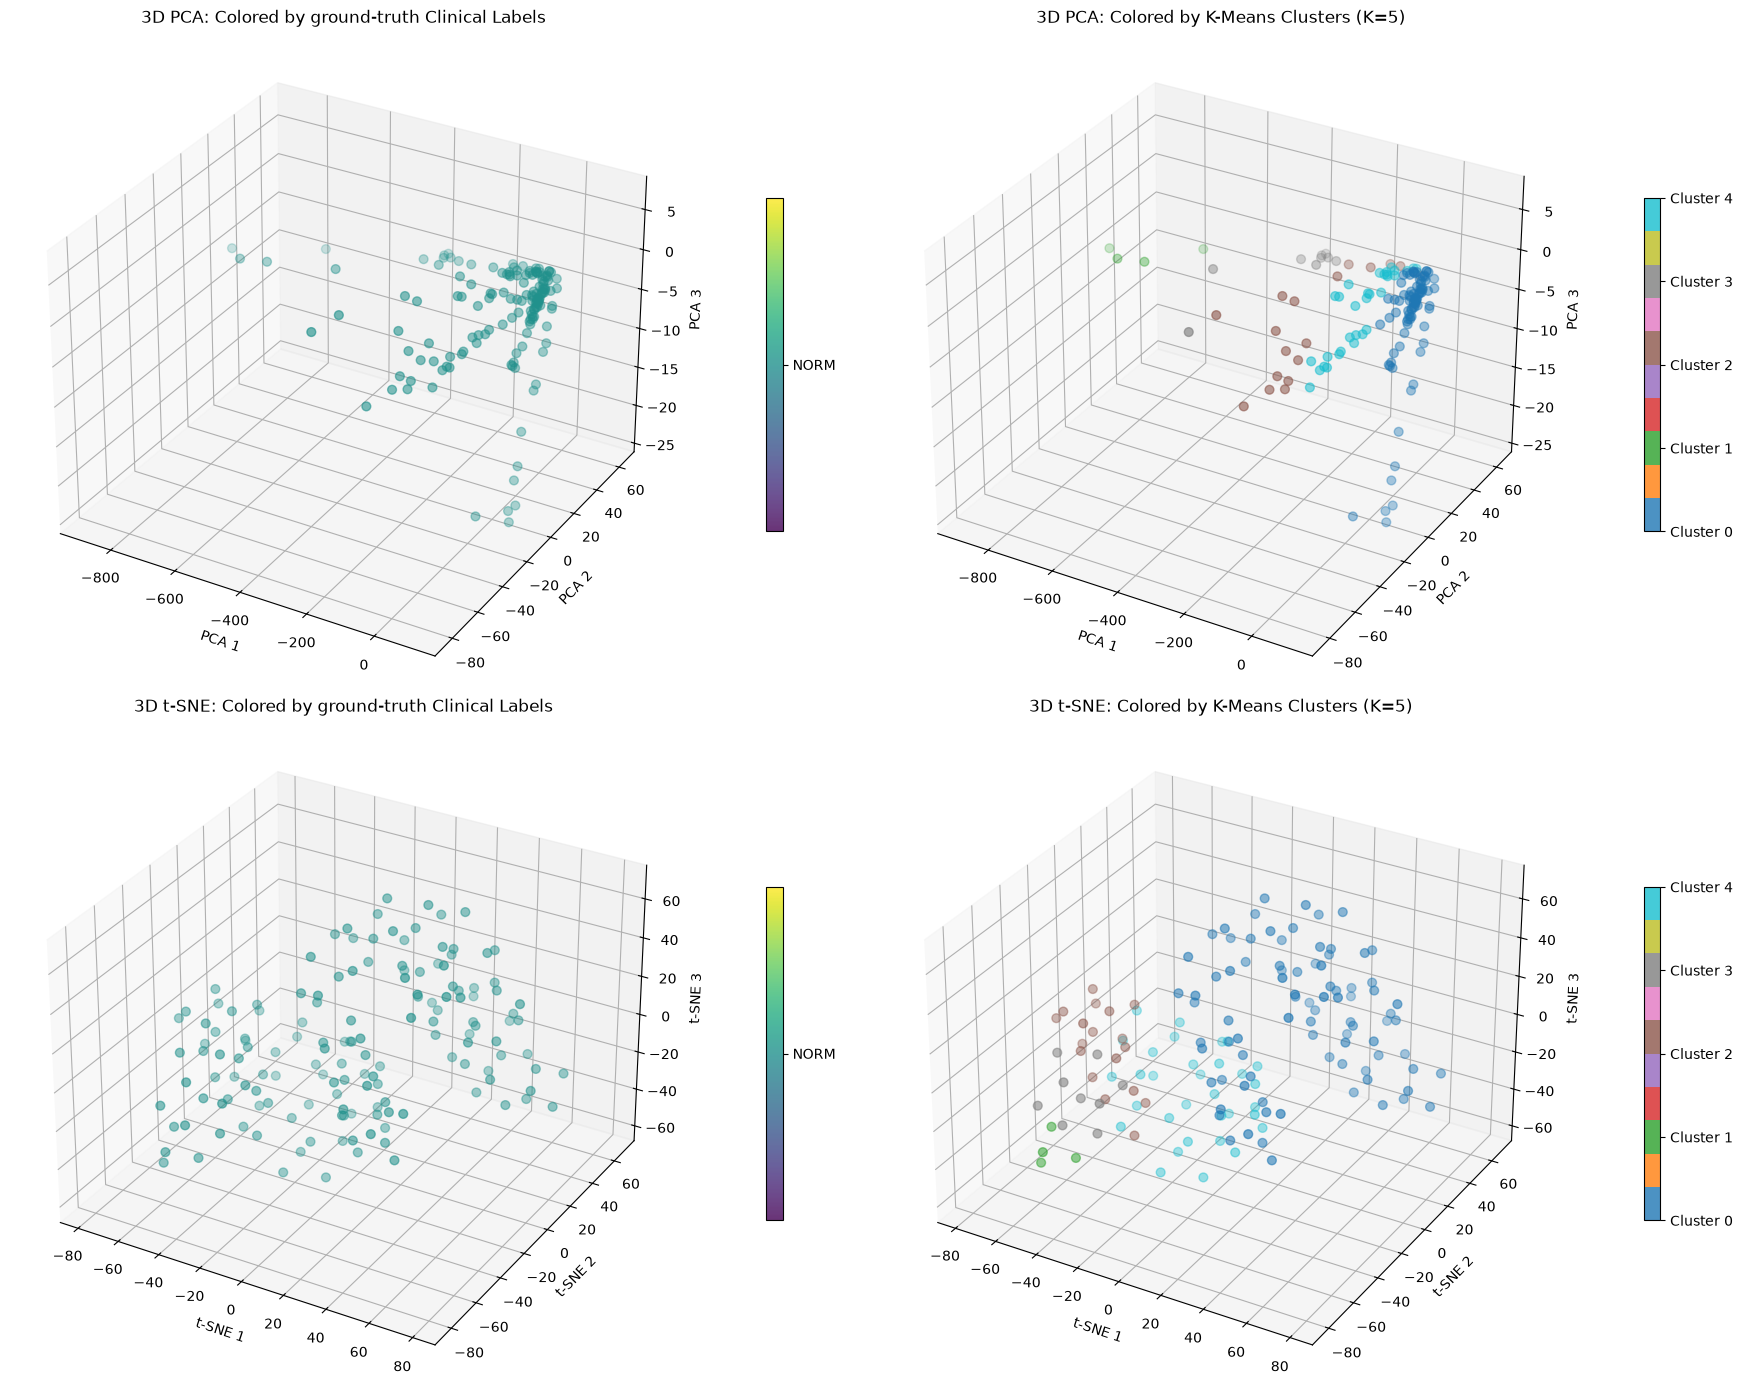

In [31]:
# 1. Run K-Means Clustering on the latent embeddings
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(test_embeddings)

# 2. Dimensionality reduction to 3D
perplexity = min(30, max(1, len(test_embeddings) - 1))
tsne_3d = TSNE(n_components=3, perplexity=perplexity, random_state=42)
tsne_coords = tsne_3d.fit_transform(test_embeddings)

pca_3d = PCA(n_components=3, random_state=42)
pca_coords = pca_3d.fit_transform(test_embeddings)

# Map ground truth clinical labels
clinical_labels = np.argmax(y_test, axis=1)
label_names = preprocessor.label_cols

# 3. Plotting comparison
fig = plt.figure(figsize=(18, 14))

# Plot 1: 3D PCA - Colored by Clinical Labels
ax1 = fig.add_subplot(221, projection='3d')
sc1 = ax1.scatter(pca_coords[:, 0], pca_coords[:, 1], pca_coords[:, 2], c=clinical_labels, cmap='viridis', s=40, alpha=0.8)
ax1.set_title("3D PCA: Colored by ground-truth Clinical Labels")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")
ax1.set_zlabel("PCA 3")
cbar1 = fig.colorbar(sc1, ax=ax1, ticks=range(len(label_names)), shrink=0.5, pad=0.1)
cbar1.set_ticklabels(label_names)

# Plot 2: 3D PCA - Colored by K-Means Clusters
ax2 = fig.add_subplot(222, projection='3d')
sc2 = ax2.scatter(pca_coords[:, 0], pca_coords[:, 1], pca_coords[:, 2], c=kmeans_labels, cmap='tab10', s=40, alpha=0.8)
ax2.set_title("3D PCA: Colored by K-Means Clusters (K=5)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_zlabel("PCA 3")
cbar2 = fig.colorbar(sc2, ax=ax2, ticks=range(5), shrink=0.5, pad=0.1)
cbar2.set_ticklabels([f"Cluster {i}" for i in range(5)])

# Plot 3: 3D t-SNE - Colored by Clinical Labels
ax3 = fig.add_subplot(223, projection='3d')
sc3 = ax3.scatter(tsne_coords[:, 0], tsne_coords[:, 1], tsne_coords[:, 2], c=clinical_labels, cmap='viridis', s=40, alpha=0.8)
ax3.set_title("3D t-SNE: Colored by ground-truth Clinical Labels")
ax3.set_xlabel("t-SNE 1")
ax3.set_ylabel("t-SNE 2")
ax3.set_zlabel("t-SNE 3")
cbar3 = fig.colorbar(sc3, ax=ax3, ticks=range(len(label_names)), shrink=0.5, pad=0.1)
cbar3.set_ticklabels(label_names)

# Plot 4: 3D t-SNE - Colored by K-Means Clusters
ax4 = fig.add_subplot(224, projection='3d')
sc4 = ax4.scatter(tsne_coords[:, 0], tsne_coords[:, 1], tsne_coords[:, 2], c=kmeans_labels, cmap='tab10', s=40, alpha=0.8)
ax4.set_title("3D t-SNE: Colored by K-Means Clusters (K=5)")
ax4.set_xlabel("t-SNE 1")
ax4.set_ylabel("t-SNE 2")
ax4.set_zlabel("t-SNE 3")
cbar4 = fig.colorbar(sc4, ax=ax4, ticks=range(5), shrink=0.5, pad=0.1)
cbar4.set_ticklabels([f"Cluster {i}" for i in range(5)])

plt.tight_layout()
plt.show()